In [1]:
"""
Notebook 02: Data Pipeline
========================================
目标：
1. 下载 30 只大盘股 + SPY 基准的 5 年历史数据
2. 清洗、对齐、保存
3. 为后续动量策略做准备
"""

import pandas as pd
import numpy as np
import akshare as ak
import matplotlib.pyplot as plt
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

# 配置
START_DATE = '2020-01-01'  # 5 年数据，足够计算 12 月动量
END_DATE = '2026-04-28'

# 股票池：S&P 500 中的大盘股（科技 + 金融 + 消费 + 工业 + 医药 + 能源）
TICKERS = [
    # Tech (10)
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA', 'AVGO', 'ORCL', 'CRM',
    # Finance (5)
    'JPM', 'BAC', 'WFC', 'GS', 'MS',
    # Consumer (5)
    'WMT', 'HD', 'NKE', 'MCD', 'KO',
    # Industrial (4)
    'BA', 'CAT', 'GE', 'HON',
    # Healthcare (4)
    'JNJ', 'PFE', 'UNH', 'LLY',
    # Energy (2)
    'XOM', 'CVX'
]

BENCHMARK = 'SPY'  # 标普 500 ETF 作为基准

print(f"股票池大小: {len(TICKERS)}")
print(f"时间范围: {START_DATE} 至 {END_DATE}")
print(f"基准: {BENCHMARK}")

股票池大小: 30
时间范围: 2020-01-01 至 2026-04-28
基准: SPY


In [2]:
def download_us_stock(ticker, start_date, end_date):
    """
    下载单只美股数据
    
    参数:
        ticker: 股票代码 (如 'AAPL')
        start_date: 起始日期 ('YYYY-MM-DD')
        end_date: 结束日期 ('YYYY-MM-DD')
    
    返回:
        DataFrame，列：open, high, low, close, volume
        索引：date
    """
    try:
        data = ak.stock_us_daily(symbol=ticker, adjust="qfq")
        data['date'] = pd.to_datetime(data['date'])
        data = data.set_index('date')
        data = data[start_date:end_date]
        data = data[['open', 'high', 'low', 'close', 'volume']]
        return data
    except Exception as e:
        print(f"下载 {ticker} 失败: {e}")
        return None


# 测试一下：下载 AAPL
test_data = download_us_stock('AAPL', START_DATE, END_DATE)
print(f"AAPL 数据形状: {test_data.shape}")
print(test_data.head(3))
print()
print(test_data.tail(3))

AAPL 数据形状: (1588, 5)
               open     high      low    close      volume
date                                                      
2020-01-02  67.9975  69.0875  67.7350  69.0250  33911864.0
2020-01-03  68.2250  69.0825  68.0625  68.2950  36633878.0
2020-01-06  67.3850  68.9275  67.1250  68.8875  29644644.0

               open    high     low   close      volume
date                                                   
2026-04-24  272.755  273.06  269.65  271.06  38156959.0
2026-04-27  266.090  268.36  265.07  267.61  41466553.0
2026-04-28  272.335  273.23  268.66  270.71  40018566.0


In [3]:
def download_universe(tickers, start_date, end_date, save_path='../data/'):
    """
    批量下载股票池数据
    """
    os.makedirs(save_path, exist_ok=True)
    
    all_data = {}
    failed = []
    
    for i, ticker in enumerate(tickers, 1):
        print(f"[{i}/{len(tickers)}] 下载 {ticker}...", end=' ')
        
        data = download_us_stock(ticker, start_date, end_date)
        
        if data is not None and len(data) > 0:
            all_data[ticker] = data
            data.to_csv(f"{save_path}{ticker}.csv")
            print(f"OK {len(data)} 行")
        else:
            failed.append(ticker)
            print("FAILED")
    
    print(f"\n=== 下载完成 ===")
    print(f"成功: {len(all_data)}/{len(tickers)}")
    if failed:
        print(f"失败: {failed}")
    
    return all_data


# 下载所有股票（包括基准 SPY）
print("开始批量下载...")
universe = download_universe(TICKERS + [BENCHMARK], START_DATE, END_DATE)
print(f"\n股票池实际可用: {len(universe)} 只")

开始批量下载...
[1/31] 下载 AAPL... OK 1588 行
[2/31] 下载 MSFT... OK 1588 行
[3/31] 下载 GOOGL... OK 1588 行
[4/31] 下载 AMZN... OK 1588 行
[5/31] 下载 META... OK 974 行
[6/31] 下载 NVDA... OK 1588 行
[7/31] 下载 TSLA... OK 1588 行
[8/31] 下载 AVGO... OK 1588 行
[9/31] 下载 ORCL... OK 1588 行
[10/31] 下载 CRM... OK 1588 行
[11/31] 下载 JPM... OK 1588 行
[12/31] 下载 BAC... OK 1588 行
[13/31] 下载 WFC... OK 1588 行
[14/31] 下载 GS... OK 1588 行
[15/31] 下载 MS... OK 1588 行
[16/31] 下载 WMT... OK 1588 行
[17/31] 下载 HD... OK 1588 行
[18/31] 下载 NKE... OK 1588 行
[19/31] 下载 MCD... OK 1588 行
[20/31] 下载 KO... OK 1588 行
[21/31] 下载 BA... OK 1588 行
[22/31] 下载 CAT... OK 1588 行
[23/31] 下载 GE... OK 1588 行
[24/31] 下载 HON... OK 1247 行
[25/31] 下载 JNJ... OK 1588 行
[26/31] 下载 PFE... OK 1588 行
[27/31] 下载 UNH... OK 1588 行
[28/31] 下载 LLY... OK 1588 行
[29/31] 下载 XOM... OK 1588 行
[30/31] 下载 CVX... OK 1588 行
[31/31] 下载 SPY... OK 1588 行

=== 下载完成 ===
成功: 31/31

股票池实际可用: 31 只


In [4]:
def build_price_panel(universe):
    """
    把所有股票的收盘价整合成一个 DataFrame
    
    返回:
        DataFrame: 行=日期, 列=股票代码, 值=收盘价
    """
    prices = pd.DataFrame()
    
    for ticker, data in universe.items():
        prices[ticker] = data['close']
    
    return prices


# 整合
prices = build_price_panel(universe)
print(f"价格面板形状: {prices.shape}")
print(f"日期范围: {prices.index[0]} 至 {prices.index[-1]}")
print(f"\n前 3 行（每列是一只股票）：")
print(prices.head(3))

价格面板形状: (1588, 31)
日期范围: 2020-01-02 00:00:00 至 2026-04-28 00:00:00

前 3 行（每列是一只股票）：
               AAPL    MSFT    GOOGL     AMZN  META    NVDA     TSLA    AVGO  \
date                                                                           
2020-01-02  69.0250  143.51  66.7940  94.9005   NaN  5.8498  28.6840  20.579   
2020-01-03  68.2950  141.51  66.4360  93.7485   NaN  5.7538  29.5340  19.759   
2020-01-06  68.8875  141.92  68.2505  95.1440   NaN  5.7785  30.1027  19.712   

             ORCL      CRM  ...     CAT     GE  HON     JNJ    PFE     UNH  \
date                        ...                                              
2020-01-02  44.09  163.286  ...  118.23  91.13  NaN  118.54  28.56  249.26   
2020-01-03  43.90  162.466  ...  116.14  91.45  NaN  116.85  28.35  246.30   
2020-01-06  44.18  169.746  ...  116.04  92.81  NaN  116.67  28.30  248.31   

               LLY    XOM    CVX       SPY  
date                                        
2020-01-02  104.48  47.83  84.10  

In [5]:
# 缺失值检查
missing = prices.isnull().sum()
print("=== 缺失值统计 ===")
print(missing[missing > 0] if missing.sum() > 0 else "没有缺失值")
print()

# 处理缺失值（前向填充，最多 5 天）
prices_clean = prices.fillna(method='ffill', limit=5)

# 删除仍然缺失的（说明数据完全没有）
prices_clean = prices_clean.dropna(how='all')

print(f"清洗后形状: {prices_clean.shape}")

=== 缺失值统计 ===
META    614
HON     341
dtype: int64

清洗后形状: (1588, 31)


In [6]:
# 计算日收益率
returns = prices_clean.pct_change().dropna()

print(f"收益率面板形状: {returns.shape}")

# 年化收益和波动率统计
stats = pd.DataFrame({
    'annual_return': returns.mean() * 252,
    'annual_vol': returns.std() * np.sqrt(252),
    'sharpe': (returns.mean() * 252 - 0.04) / (returns.std() * np.sqrt(252))
}).sort_values('sharpe', ascending=False)

print("\n=== 表现最好的 10 只 ===")
print(stats.head(10))

print("\n=== 表现最差的 5 只 ===")
print(stats.tail(5))

收益率面板形状: (973, 31)

=== 表现最好的 10 只 ===
       annual_return  annual_vol    sharpe
NVDA        0.769286    0.508236  1.434935
WMT         0.344723    0.219452  1.388566
AVGO        0.664263    0.473494  1.318418
CAT         0.414159    0.322730  1.159356
GE          0.423575    0.342018  1.121505
GS          0.371672    0.297563  1.114628
JPM         0.312753    0.260149  1.048449
GOOGL       0.343191    0.319206  0.949827
META        0.435803    0.433869  0.912263
LLY         0.348290    0.337970  0.912184

=== 表现最差的 5 只 ===
     annual_return  annual_vol    sharpe
HON       0.075259    0.225557  0.156319
CRM       0.064075    0.364557  0.066039
UNH       0.006440    0.350801 -0.095666
PFE      -0.105237    0.271446 -0.535050
NKE      -0.166108    0.376376 -0.547612


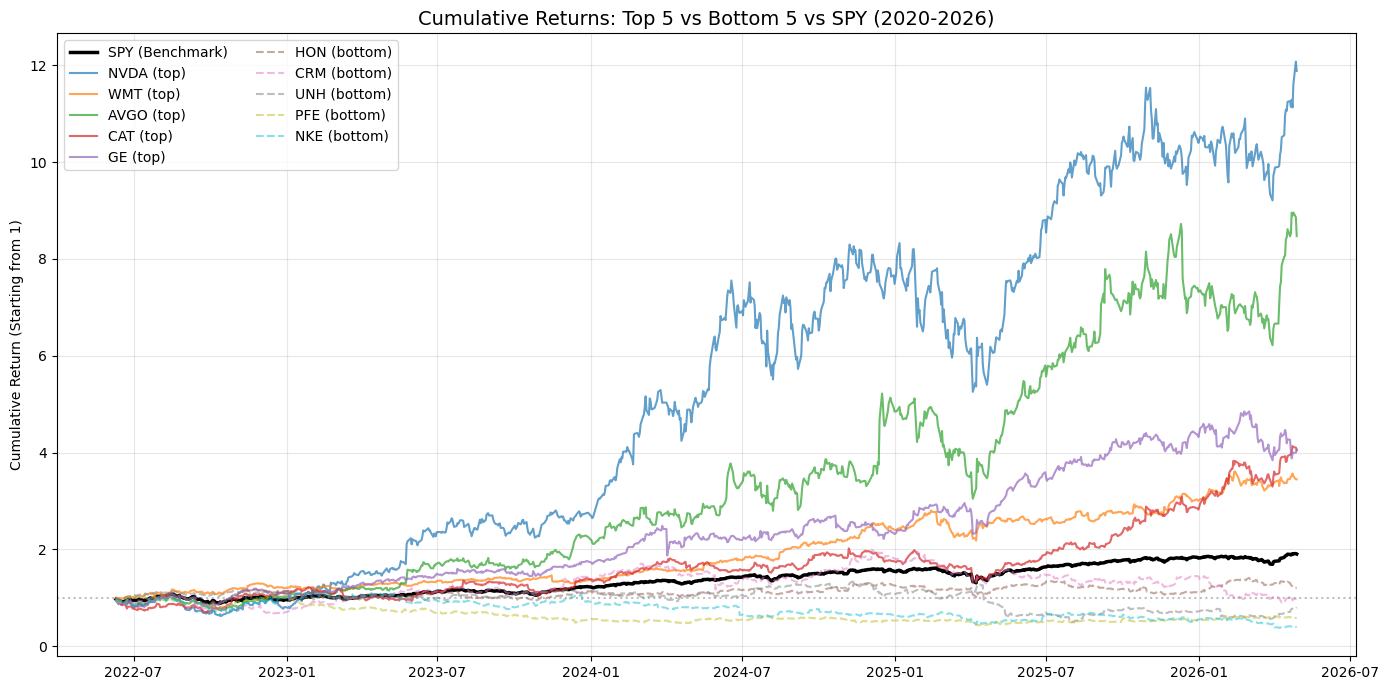


数据已保存:
  - data/prices_panel.csv ((1588, 31))
  - data/returns_panel.csv ((973, 31))
  - reports/02_universe_stats.csv
  - reports/02_universe_overview.png


In [7]:
# 画累计收益对比图
fig, ax = plt.subplots(figsize=(14, 7))

cumulative = (1 + returns).cumprod()

# 画 SPY 基准（粗黑线）
ax.plot(cumulative.index, cumulative['SPY'], 
        label='SPY (Benchmark)', color='black', linewidth=2.5)

# 画前 5 强（实线）
top5 = stats.head(5).index.tolist()
for ticker in top5:
    if ticker != 'SPY':
        ax.plot(cumulative.index, cumulative[ticker], label=f'{ticker} (top)', alpha=0.7)

# 画后 5 弱（虚线）
bottom5 = stats.tail(5).index.tolist()
for ticker in bottom5:
    if ticker != 'SPY':
        ax.plot(cumulative.index, cumulative[ticker], 
                label=f'{ticker} (bottom)', alpha=0.5, linestyle='--')

ax.set_title('Cumulative Returns: Top 5 vs Bottom 5 vs SPY (2020-2026)', fontsize=14)
ax.set_ylabel('Cumulative Return (Starting from 1)')
ax.legend(loc='upper left', ncol=2)
ax.grid(True, alpha=0.3)
ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()

# 确保 reports 目录存在
os.makedirs('../reports/', exist_ok=True)

plt.savefig('../reports/02_universe_overview.png', dpi=100, bbox_inches='tight')
plt.show()

# 保存清洗好的数据
prices_clean.to_csv('../data/prices_panel.csv')
returns.to_csv('../data/returns_panel.csv')
stats.to_csv('../reports/02_universe_stats.csv')

print("\n数据已保存:")
print(f"  - data/prices_panel.csv ({prices_clean.shape})")
print(f"  - data/returns_panel.csv ({returns.shape})")
print(f"  - reports/02_universe_stats.csv")
print(f"  - reports/02_universe_overview.png")